In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

plt.rcParams.update({"font.size":16, "axes.labelsize":16})

For full credit, do not program in any constants yourself. Use the <tt>scipy</tt> versions, which the cell above will import for you. Use <tt>numpy</tt> arrays instead of lists.

### Spacetime coordinate axes

Recall that in PHYS 207, you were often asked to plot displacement as a function of time. For example, for a baseball thrown directly upward you would plot $y(t)$, and for a block on a horizontal spring you would plot $x(t)$. Here we will examine how the displacement and time axes "scissor together" at relativistic speeds.

The convention in relativity is to reverse the axes: $ct$ is vertical and $x$ is horizontal. Time moves forward from the bottom to the top of the plot:

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

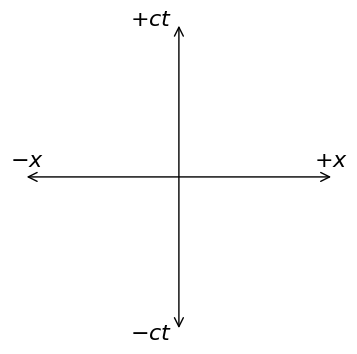

In [3]:
plt.figure(figsize=(4,4))
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.annotate(text='', xy=(-1,0), xytext=(1,0), arrowprops=dict(arrowstyle='<->'))
plt.annotate(text='', xy=(0,-1), xytext=(0,1), arrowprops=dict(arrowstyle='<->'))
plt.text(0.98, 0.04, r"$+x$", horizontalalignment='center', verticalalignment='bottom')
plt.text(-0.98, 0.04, r"$-x$", horizontalalignment='center', verticalalignment='bottom')
plt.text(-0.04, 1.02, r"$+ct$", horizontalalignment='right', verticalalignment='center')
plt.text(-0.04, -1.02, r"$-ct$", horizontalalignment='right', verticalalignment='center')
plt.axis('off')

Imagine that frame $K^{\prime}$ is moving in the $+x$ direction at speed $v$ relative to frame $K$. You are at rest in frame $K$. Let's figure out how the set of $(x^{\prime}, ct^{\prime})$ axes would look to you when the frames' origins $O$ and $O^{\prime}$ coincide.

<ol>
    <li>Use the fact that $x^{\prime} = 0$ on the $ct^{\prime}$ axis to define a line $ct(x)$ in frame $K$ that follows the $ct^{\prime}$ axis. Write a function that computes points on the line. $v$ will be one of your function inputs.</li>
</ol>

In [17]:
def ct_prime_axis(x, v):
    
    beta = v / constants.c
    return x / beta

<ol start=2>
    <li>Use the fact that $ct^{\prime} = 0$ on the $x^{\prime}$ axis to define a line $ct(x)$ that traces the $x^{\prime}$ axis in frame $K$. Write a second function that computes points on this line.</li>
</ol>

In [18]:
def x_prime_axis(x, v):

    beta = v / constants.c
    return beta * x

<ol start=3>
    <li>The code below creates a figure with centered $(x, ct)$ axes that have range $(-10^{10}, 10^{10})$ m. We are using $ct$ instead of just $t$ on our vertical axis so that both axes have the same units. Use your functions from problems 1 and 2 to overplot the $ct^{\prime}$ and $x^{\prime}$ axes <strong>as a function of $x$</strong> for $v = 0.2c$. Make your $ct^{\prime}$ and $x^{\prime}$ axes red, and label them in red. Also add black labels to the $(x, ct)$ axes giving the coordinate name ($x$ or $ct$) and the units.</li>
</ol>

Text(500000000.0, 9000000000.0, '$ct$ (m)')

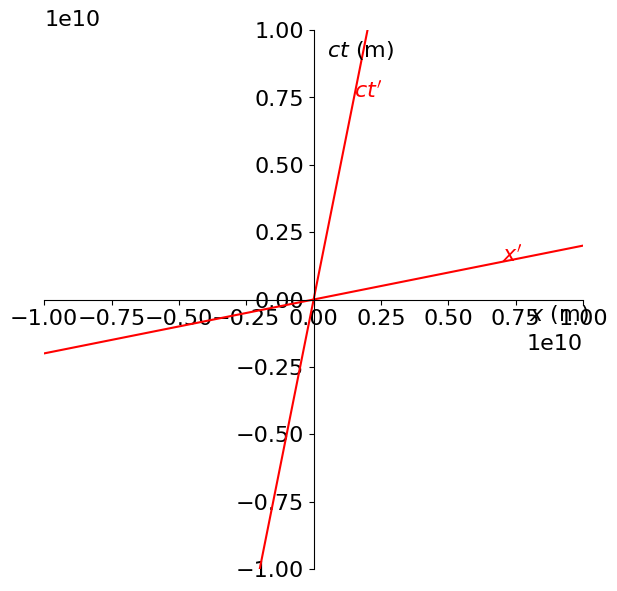

In [19]:
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(7,7))

# YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
v = 0.2 * constants.c

ax.plot(x, ct_prime_axis(x, v), color='red')
ax.plot(x, x_prime_axis(x, v), color='red')

# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# YOUR CODE HERE: Use ax.text() to add RED labels to the ct' and x' axes below

ax.text(1.5e9, ct_prime_axis(1.5e9, v), r"$ct'$", color='red')
ax.text(7e9, x_prime_axis(7e9, v), r"$x'$", color='red')

ax.text(8e9, -8e8, r"$x$ (m)", color='black')
ax.text(5e8, 9e9, r"$ct$ (m)", color='black')

<ol start=4>
    <li>Make a figure that plots $ct^{\prime}$ and $x^{\prime}$ axes for $v = 0.25c$, $v = 0.5c$, and $v = 0.75c$. Use different colors for each pair of axes. Make a legend that shows which value of $v$ corresponds to each color. Label the $(x, ct)$ axes and add units.</li>
</ol>

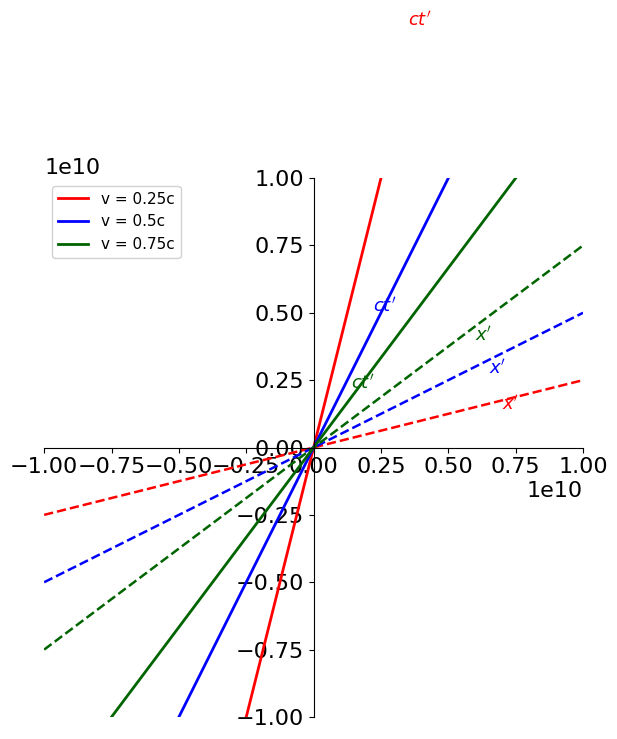

In [23]:
# Plot here. You may copy syntax from the previous cell.
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(7,7))

# YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
speeds = [0.25, 0.50, 0.75]
colors = ['red', 'blue', 'darkgreen']

for v_frac, color in zip(speeds, colors):
    v = v_frac * constants.c
    
    # Plot ct' axis (solid) and x' axis (dashed)
    ax.plot(x, ct_prime_axis(x, v), color=color, lw=2.0, 
            label=f"v = {v_frac}c")
    ax.plot(x, x_prime_axis(x, v), color=color, lw=1.8, linestyle='--')
# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# YOUR CODE HERE: Use ax.text() to add RED labels to the ct' and x' axes below
ax.text(3.5e9,  ct_prime_axis(3.5e9, 0.25*constants.c)*1.12,  r"$ct'$", color='red',    fontsize=13, fontweight='bold')
ax.text(7.0e9,  x_prime_axis(7.0e9,  0.25*constants.c)*0.80,  r"$x'$",  color='red',    fontsize=13, fontweight='bold')

ax.text(2.2e9,  ct_prime_axis(2.2e9, 0.50*constants.c)*1.15,  r"$ct'$", color='blue',   fontsize=13, fontweight='bold')
ax.text(6.5e9,  x_prime_axis(6.5e9,  0.50*constants.c)*0.85,  r"$x'$",  color='blue',   fontsize=13, fontweight='bold')

ax.text(1.4e9,  ct_prime_axis(1.4e9, 0.75*constants.c)*1.18,  r"$ct'$", color='darkgreen', fontsize=13, fontweight='bold')
ax.text(6.0e9,  x_prime_axis(6.0e9,  0.75*constants.c)*0.88,  r"$x'$",  color='darkgreen', fontsize=13, fontweight='bold')

ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

<ol start=5>
    <li>Connect your graph from problem 4 with the discussion of world lines in Chapter 2 of your textbook. What kind of world line do your $(x^{\prime}, ct^{\prime})$ axes approach as $v \rightarrow c$? Create a similar plot to problem 4, but this time plot $(x^{\prime}, ct^{\prime})$ axes for $v = 0.5, 0.75, 0.875, 0.9375$. To illustrate the concept of taking a limit as $v \rightarrow c$, make each set of $( x^{\prime}, ct^{\prime})$ axes a successively darker shade of gray. Plot the limiting world line in black. Add a legend to show which value of $v$ corresponds to which shade of gray. You may find it helpful to specify line colors like this: <tt>color='0.7'</tt>.</li>
</ol>

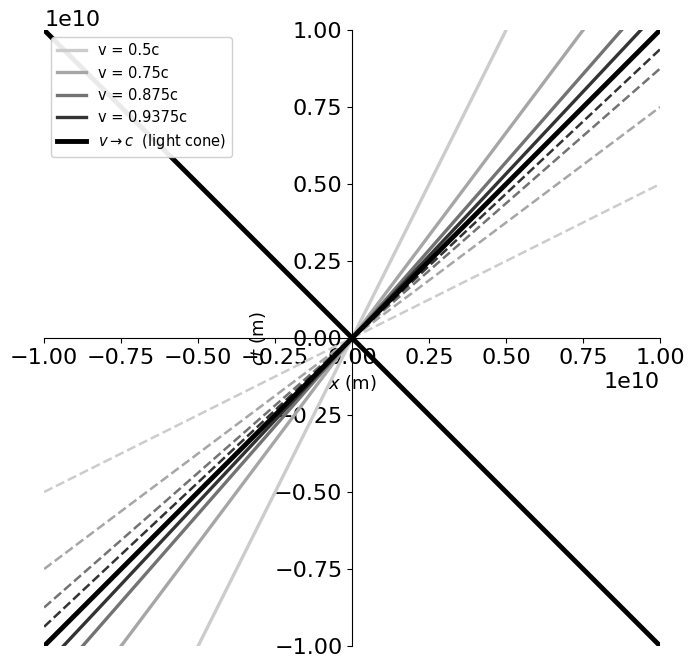

In [25]:
# Plot here
# Plot here. You may copy syntax from the previous cell.
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(8,8))

# YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
speeds = [0.50, 0.75, 0.875, 0.9375]
colors = ['0.80', '0.65', '0.45', '0.20']

for v_frac, color in zip(speeds, colors):
    v = v_frac * constants.c
    
    ax.plot(x, ct_prime_axis(x, v), color=color, lw=2.4,
            label=f"v = {v_frac}c")
    ax.plot(x, x_prime_axis(x, v), color=color, lw=1.8, linestyle='--')
    
ax.plot(x, x, color='black', lw=3.5, label=r"$v \to c$  (light cone)")
ax.plot(x, -x, color='black', lw=3.5)
# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# YOUR CODE HERE: Use ax.text() to add RED labels to the ct' and x' axes below
ax.set_xlabel(r"$x$ (m)", fontsize=13)
ax.set_ylabel(r"$ct$ (m)", fontsize=13)

ax.legend(loc='upper left', fontsize=10.5, framealpha=0.92)

#### More HIPE

From within HIPE, open and run the script called <strong><tt>scanmap_Extended_emission_JyPScanam_58Eri_green.py</tt></strong> which you will find in <strong>Computer Assignent 2</strong> on Canvas. The script will download two scan maps of the debris disk surrounding the star <a href="https://simbad.cds.unistra.fr/simbad/sim-id?Ident=58+Eri&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id">58 Eri</a> and combine them to make an image. Take a screenshot of the image that appears in the HIPE pop-up window and display it in the code cell below.

Note: You may have to make a Herschel Science Archive account and log into it from within HIPE.